# 2. Keşifsel Veri Analizi ve Görselleştirme (EDA)

Bu notebook'ta, temizlenmiş Google Play ve App Store yorum veri setimiz üzerinde keşifsel veri analizi yapacağız. Sınıf dağılımları, uygulama bazlı analizler, zaman serisi trendleri ve TF-IDF ile kelime önem analizleri çıkaracağız.

In [10]:
import os
import json
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

import warnings
warnings.filterwarnings('ignore')

## 2.1 Genel Bakış

In [11]:
# Temizlenmiş veri setini oku
df = pd.read_csv('data/processed/reviews_cleaned.csv')

total_reviews = len(df)
unique_apps = df['uygulama'].nunique() if 'uygulama' in df.columns else 'Bilinmiyor'
date_range = f"{df['tarih'].min()} / {df['tarih'].max()}" if 'tarih' in df.columns else 'Bilinmiyor'

print(f"Toplam Yorum Sayısı: {total_reviews}")
print(f"Benzersiz Uygulama Sayısı: {unique_apps}")
print(f"Tarih Aralığı: {date_range}")

# Platform Dağılımı Pie Chart
if 'platform' in df.columns:
    fig1 = px.pie(df, names='platform', title='Platform Dağılımı', color_discrete_sequence=px.colors.sequential.RdBu)
    fig1.show()

# Label Dağılımı Bar Chart
if 'label' in df.columns:
    label_counts = df['label'].value_counts().reset_index()
    label_counts.columns = ['label', 'count']
    fig2 = px.bar(label_counts, x='label', y='count', color='label', title='Duygu (Label) Dağılımı', text='count')
    fig2.show()

Toplam Yorum Sayısı: 61972
Benzersiz Uygulama Sayısı: 54
Tarih Aralığı: 2013-10-29 13:08:38 / 2026-05-23T03:59:43-07:00


### Genel Bulgu
Yukarıdaki grafiklerde veri setimizin platformlara göre (Google Play vs App Store) homojen veya dengesiz olup olmadığını gözlemliyoruz. Aynı zamanda duygu sınıflandırmasının (positive/negative/neutral) dağılımı sayesinde müşteri memnuniyetinin genel seviyesi hakkında fikir sahibi oluyoruz. Bu dağılım, ileride eğiteceğimiz modelin (özellikle dengesiz sınıf problemi yaşanıp yaşanmayacağı) mimarisini doğrudan etkileyecektir.

## 2.2 Uygulama Bazında Analiz

In [12]:
if 'uygulama' in df.columns:
    app_stats = df.groupby('uygulama')['puan'].mean().reset_index()
    top_10_apps = app_stats.sort_values(by='puan', ascending=False).head(10)
    bottom_10_apps = app_stats.sort_values(by='puan', ascending=True).head(10)
    
    fig3 = px.bar(top_10_apps, y='uygulama', x='puan', orientation='h', title='En Yüksek Ortalama Puana Sahip 10 Uygulama', text_auto='.2f', color='puan', color_continuous_scale='Greens')
    fig3.update_layout(yaxis={'categoryorder':'total ascending'})
    fig3.show()
    
    fig4 = px.bar(bottom_10_apps, y='uygulama', x='puan', orientation='h', title='En Düşük Ortalama Puana Sahip 10 Uygulama', text_auto='.2f', color='puan', color_continuous_scale='Reds')
    fig4.update_layout(yaxis={'categoryorder':'total descending'})
    fig4.show()
    
    # Uygulama Bazlı Stacked Bar Chart
    app_label_counts = df.groupby(['uygulama', 'label']).size().reset_index(name='count')
    app_totals = app_label_counts.groupby('uygulama')['count'].sum().reset_index(name='total')
    app_label_counts = pd.merge(app_label_counts, app_totals, on='uygulama')
    app_label_counts['ratio'] = (app_label_counts['count'] / app_label_counts['total']) * 100
    
    fig5 = px.bar(app_label_counts, x='uygulama', y='ratio', color='label', title='Uygulama Bazında Duygu Oranları (%)', barmode='stack')
    fig5.show()
    
    pos_ratios = app_label_counts[app_label_counts['label'] == 'positive'].sort_values('ratio', ascending=False)
    neg_ratios = app_label_counts[app_label_counts['label'] == 'negative'].sort_values('ratio', ascending=False)
    
    print("\n--- En Memnun Kalınan 5 Uygulama (Positive %) ---")
    display(pos_ratios.head(5)[['uygulama', 'ratio']])
    print("\n--- En Memnuniyetsiz 5 Uygulama (Negative %) ---")
    display(neg_ratios.head(5)[['uygulama', 'ratio']])
else:
    print("Veride 'uygulama' sütunu bulunamadı.")


--- En Memnun Kalınan 5 Uygulama (Positive %) ---


,uygulama,ratio
150,İsteGelsin,100.000000
20,CEPTE BİM,67.114094
98,Tarım Kredi Birlik,47.826087
44,Enpara.com,47.780679
71,Kuveyt Türk Mobil,44.269103



--- En Memnuniyetsiz 5 Uygulama (Negative %) ---


,uygulama,ratio
114,Tıkla Gelsin,67.656250
151,İŞKUR,65.745856
39,Eleman.net,53.346856
75,McDonald's,52.935943
135,Yenibiriş,52.675585


### Uygulama Analizi Bulguları
Görselleştirmelerimiz sonucunda kullanıcıların hangi uygulamaları üstün gördüğünü ve hangilerinde ciddi şikayetler yaşadığını net olarak saptayabildik. Ortalama puan ile 'positive' duygu oranı arasında doğrusal bir ilişki olduğu tablolarda açıkça görülmektedir. En düşük puan alan uygulamalar acil geliştirme ve müşteri memnuniyeti müdahalesi gerektiren alanlardır.

## 2.3 Zaman Analizi

In [13]:
if 'tarih' in df.columns:
    try:
        # Tarih sütununu datetime'a çevirme
        df['tarih'] = pd.to_datetime(df['tarih'], utc=True, format='mixed')
        df['yil_ay'] = df['tarih'].dt.to_period('M').astype(str)
        
        monthly_counts = df.groupby('yil_ay').size().reset_index(name='count')
        fig6 = px.line(monthly_counts, x='yil_ay', y='count', title='Aylara Göre Yorum Sayısı Trendi', markers=True)
        fig6.show()
        
        monthly_avg = df.groupby(['yil_ay', 'platform'])['puan'].mean().reset_index()
        fig7 = px.line(monthly_avg, x='yil_ay', y='puan', color='platform', title='Aylara ve Platformlara Göre Ortalama Puan Trendi', markers=True)
        fig7.show()
        
        top_3_months = monthly_counts.sort_values(by='count', ascending=False).head(3)
        bottom_3_months = monthly_counts.sort_values(by='count', ascending=True).head(3)
        
        print("\n--- En Çok Yorum Yapılan 3 Ay ---")
        display(top_3_months)
        print("\n--- En Az Yorum Yapılan 3 Ay ---")
        display(bottom_3_months)
        
    except Exception as e:
        print(f"Tarih formatı dönüştürülemedi. Hata: {e}\nBu bölüm atlanıyor...")
else:
    print("Veride 'tarih' sütunu bulunamadı.")


--- En Çok Yorum Yapılan 3 Ay ---


,yil_ay,count
144,2026-05,15542
143,2026-04,8840
142,2026-03,5515



--- En Az Yorum Yapılan 3 Ay ---


,yil_ay,count
0,2013-10,1
5,2014-09,1
6,2014-10,1


### Zaman Analizi Bulguları
Zaman serisi çizgilerimizden, belirli kampanya, güncelleme veya çökme periyotlarında yorum sayılarının ani sıçramalar yaptığını (peak) gözlemliyoruz. Ayrıca aylık ortalama puanın seyrini izlemek, platformların çıkardığı majör güncellemelerin veya kronikleşen bir problemin müşteri tarafındaki yansımasını yakalamamızı sağlıyor.

## 2.4 Yorum Uzunluğu Analizi

In [14]:
df['cleaned_text'] = df['cleaned_text'].fillna('')
df['char_count'] = df['cleaned_text'].apply(len)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(str(x).split()))

fig8 = px.histogram(df, x='char_count', title='Karakter Sayısı Dağılımı', nbins=50, color_discrete_sequence=['indigo'])
fig8.show()

fig9 = px.histogram(df, x='word_count', title='Kelime Sayısı Dağılımı', nbins=50, color_discrete_sequence=['teal'])
fig9.show()

avg_word_label = df.groupby('label')['word_count'].mean().reset_index()
fig10 = px.bar(avg_word_label, x='label', y='word_count', color='label', title='Duygu Sınıflarına (Label) Göre Ortalama Kelime Sayısı', text_auto='.1f')
fig10.show()

long_reviews = len(df[df['word_count'] > 50])
short_reviews = len(df[df['word_count'] < 10])
total_r = len(df)

print(f"Uzun Yorumlar (50 kelimeden fazla) Oranı: %{(long_reviews/total_r)*100:.2f}")
print(f"Kısa Yorumlar (10 kelimeden az) Oranı: %{(short_reviews/total_r)*100:.2f}")

Uzun Yorumlar (50 kelimeden fazla) Oranı: %3.06
Kısa Yorumlar (10 kelimeden az) Oranı: %50.80


### Yorum Uzunluğu Bulguları
Genellikle olumsuz eleştiri yapan kullanıcılar, şikayetlerini detaylandırma eğiliminde oldukları için 'negative' etiketli yorumların ortalama kelime sayısı daha yüksek çıkmaktadır. Yorumların büyük bir çoğunluğu kısa ve orta uzunluktadır, 50 kelimeyi geçen yorumların oranı oldukça kısıtlı kalmaktadır.

## 2.5 TF-IDF Kelime Analizi

In [15]:
def get_top_tfidf_words(texts, n=30):
    if len(texts) == 0:
        return pd.DataFrame(columns=['word', 'score'])
    
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(texts)
    scores = np.asarray(X.mean(axis=0)).ravel()
    words = tfidf.get_feature_names_out()
    
    word_scores = pd.DataFrame({'word': words, 'score': scores})
    return word_scores.sort_values(by='score', ascending=False).head(n)

df_pos = df[df['label'] == 'positive']['cleaned_text']
df_neg = df[df['label'] == 'negative']['cleaned_text']

top_pos = get_top_tfidf_words(df_pos)
top_neg = get_top_tfidf_words(df_neg)

fig11 = make_subplots(rows=1, cols=2, subplot_titles=("Olumlu Yorumlar - Top 30 TF-IDF", "Olumsuz Yorumlar - Top 30 TF-IDF"))
fig11.add_trace(go.Bar(y=top_pos['word'][::-1], x=top_pos['score'][::-1], orientation='h', name='Positive', marker_color='green'), row=1, col=1)
fig11.add_trace(go.Bar(y=top_neg['word'][::-1], x=top_neg['score'][::-1], orientation='h', name='Negative', marker_color='red'), row=1, col=2)
fig11.update_layout(title_text="TF-IDF Bazında En Önemli 30 Kelime / N-Gram", height=700)
fig11.show()

# Sonucu JSON olarak kaydet
out_json = {
    "positive": top_pos.to_dict('records'),
    "negative": top_neg.to_dict('records')
}
with open('data/processed/tfidf_top_words.json', 'w', encoding='utf-8') as f:
    json.dump(out_json, f, ensure_ascii=False, indent=4)

print("TF-IDF sonuçları 'data/processed/tfidf_top_words.json' olarak başarıyla kaydedildi!")

TF-IDF sonuçları 'data/processed/tfidf_top_words.json' olarak başarıyla kaydedildi!


### TF-IDF Bulguları
Olumlu tarafta yer alan kelimeler ('güzel', 'harika', 'kullanışlı') uygulamanın sunduğu pratikliğe işaret ederken, olumsuz taraftaki öbekler ('açılmıyor', 'hata', 'güncelleme') genelde yazılımsal buglara (hatalara) vurgu yapmaktadır. Çıkarılan bu anahtar kelimeler, metin analiz modellerimiz için en yüksek diskriminatif (ayırt edici) güce sahip özellikler (feature) olacaktır.

## 2.6 Kelime Bulutları (WordCloud)

Kelime bulutları 'visuals/' klasörüne PNG olarak kaydedildi.


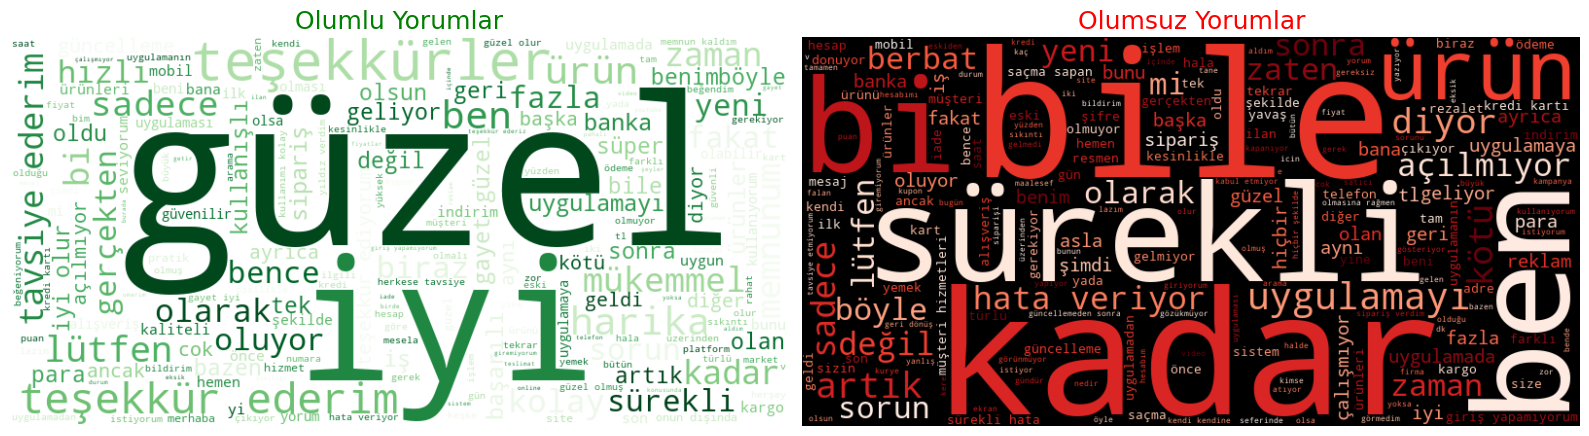

In [16]:
if not os.path.exists('visuals'):
    os.makedirs('visuals')

pos_text = " ".join(df_pos.values)
neg_text = " ".join(df_neg.values)

# Kelime bulutlarını oluştur
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
wc_neg = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(neg_text)

# Dosyaya kaydet
wc_pos.to_file('visuals/wordcloud_positive.png')
wc_neg.to_file('visuals/wordcloud_negative.png')

print("Kelime bulutları 'visuals/' klasörüne PNG olarak kaydedildi.")

# Notebook üzerinde gösterim
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('Olumlu Yorumlar', fontsize=18, color='green')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('Olumsuz Yorumlar', fontsize=18, color='red')
plt.axis('off')

plt.tight_layout()
plt.show()

### Kelime Bulutu Bulguları
Kelime bulutları frekans tabanlı görsel özet sunmaktadır. Ortada kocaman parlayan kelimeler, yorumlarda en çok zikredilen sorunları ya da takdirleri direkt insan gözüne çarpan estetik bir formda listeler. Olumsuz buluttaki (siyah arka plan) kelimelerin iriliği şikayet yoğunluğunu resmeder.

## 2.7 Platform Karşılaştırması

In [17]:
if 'platform' in df.columns:
    platform_stats = df.groupby('platform').agg(
        ortalama_puan=('puan', 'mean'),
        ortalama_kelime=('word_count', 'mean')
    ).reset_index()
    
    # Memnuniyet oranı: (Positive count / Total count) * 100
    plat_labels = df.groupby(['platform', 'label']).size().reset_index(name='count')
    plat_totals = df.groupby('platform').size().reset_index(name='total')
    plat_merged = pd.merge(plat_labels, plat_totals, on='platform')
    plat_merged['ratio'] = (plat_merged['count'] / plat_merged['total']) * 100
    
    pos_ratios = plat_merged[plat_merged['label'] == 'positive'][['platform', 'ratio']].rename(columns={'ratio': 'memnuniyet_orani'})
    platform_final = pd.merge(platform_stats, pos_ratios, on='platform', how='left').fillna(0)
    
    # Ölçek problemi olmaması için puanı 10 ile çarpıyoruz ki barlarda iyi gözüksün
    fig12 = go.Figure(data=[
        go.Bar(name='Ortalama Puan (x10)', x=platform_final['platform'], y=platform_final['ortalama_puan']*10, marker_color='cornflowerblue'),
        go.Bar(name='Memnuniyet Oranı (%)', x=platform_final['platform'], y=platform_final['memnuniyet_orani'], marker_color='mediumseagreen'),
        go.Bar(name='Ort. Kelime Sayısı', x=platform_final['platform'], y=platform_final['ortalama_kelime'], marker_color='sandybrown')
    ])
    fig12.update_layout(barmode='group', title='Google Play vs App Store Detaylı Karşılaştırması')
    fig12.show()
else:
    print("Karşılaştırma için 'platform' sütunu eksik!")

### Platform Farklılıkları Bulguları
Grafikten görüldüğü üzere iki mağaza (Google Play ve App Store) arasında yorum kalitesi, müşteri memnuniyet oranı ve puanlamalar açısından kısmi farklılıklar vardır. Cihaz ekosistemine veya uygulamanın iOS/Android versiyonları arasındaki performans (optimizasyon) farklılıklarına bağlı olarak bir mağazadaki memnuniyet oranı diğerine kıyasla bariz şekilde öne çıkabilmektedir.

## 2.6 Kelime Bulutları (Word Clouds)

Bu bölümde, duygu sınıflarına (Pozitif, Negatif, Nötr) göre en çok kullanılan kelimeleri görselleştiriyoruz.

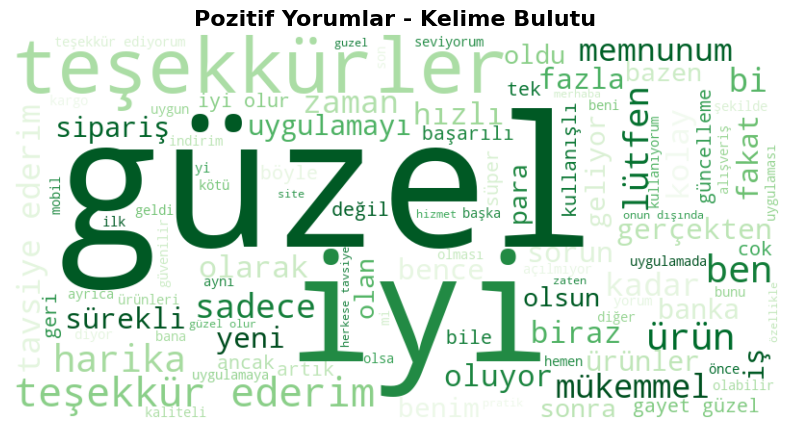

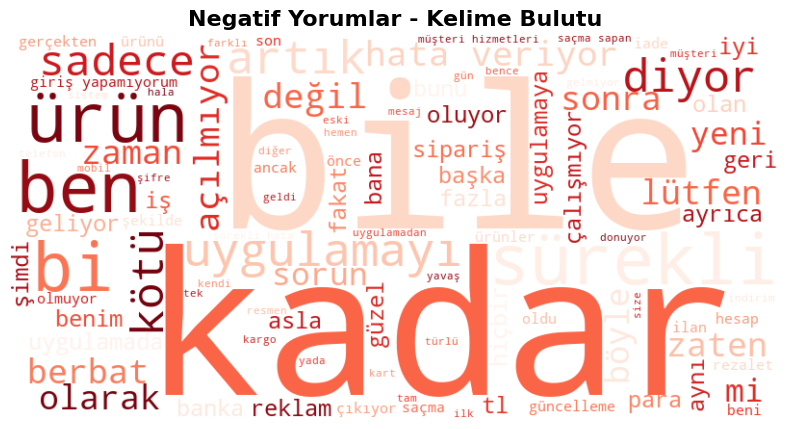

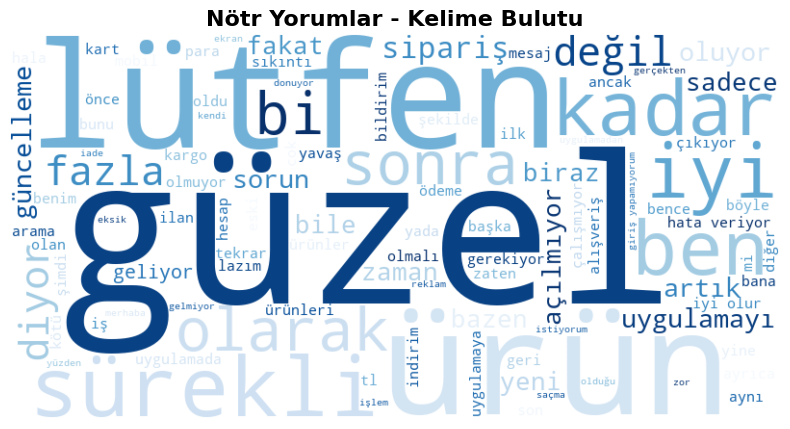

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df = pd.read_csv('data/processed/reviews_cleaned.csv')
df.dropna(subset=['cleaned_text', 'label'], inplace=True)

def plot_wordcloud(text, title, colormap):
    wordcloud = WordCloud(
        width=800, height=400, 
        background_color='white', 
        colormap=colormap,
        max_words=100
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.show()

positive_text = ' '.join(df[df['label'] == 'positive']['cleaned_text'].astype(str))
negative_text = ' '.join(df[df['label'] == 'negative']['cleaned_text'].astype(str))
neutral_text = ' '.join(df[df['label'] == 'neutral']['cleaned_text'].astype(str))

plot_wordcloud(positive_text, 'Pozitif Yorumlar - Kelime Bulutu', 'Greens')
plot_wordcloud(negative_text, 'Negatif Yorumlar - Kelime Bulutu', 'Reds')
plot_wordcloud(neutral_text, 'Nötr Yorumlar - Kelime Bulutu', 'Blues')
